# Middleware

Middleware provides a way to mode tightly control what happens inside th agent. Middleware is useful for the following:
- Tracking agent behavior with logging, analytics and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retires, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection

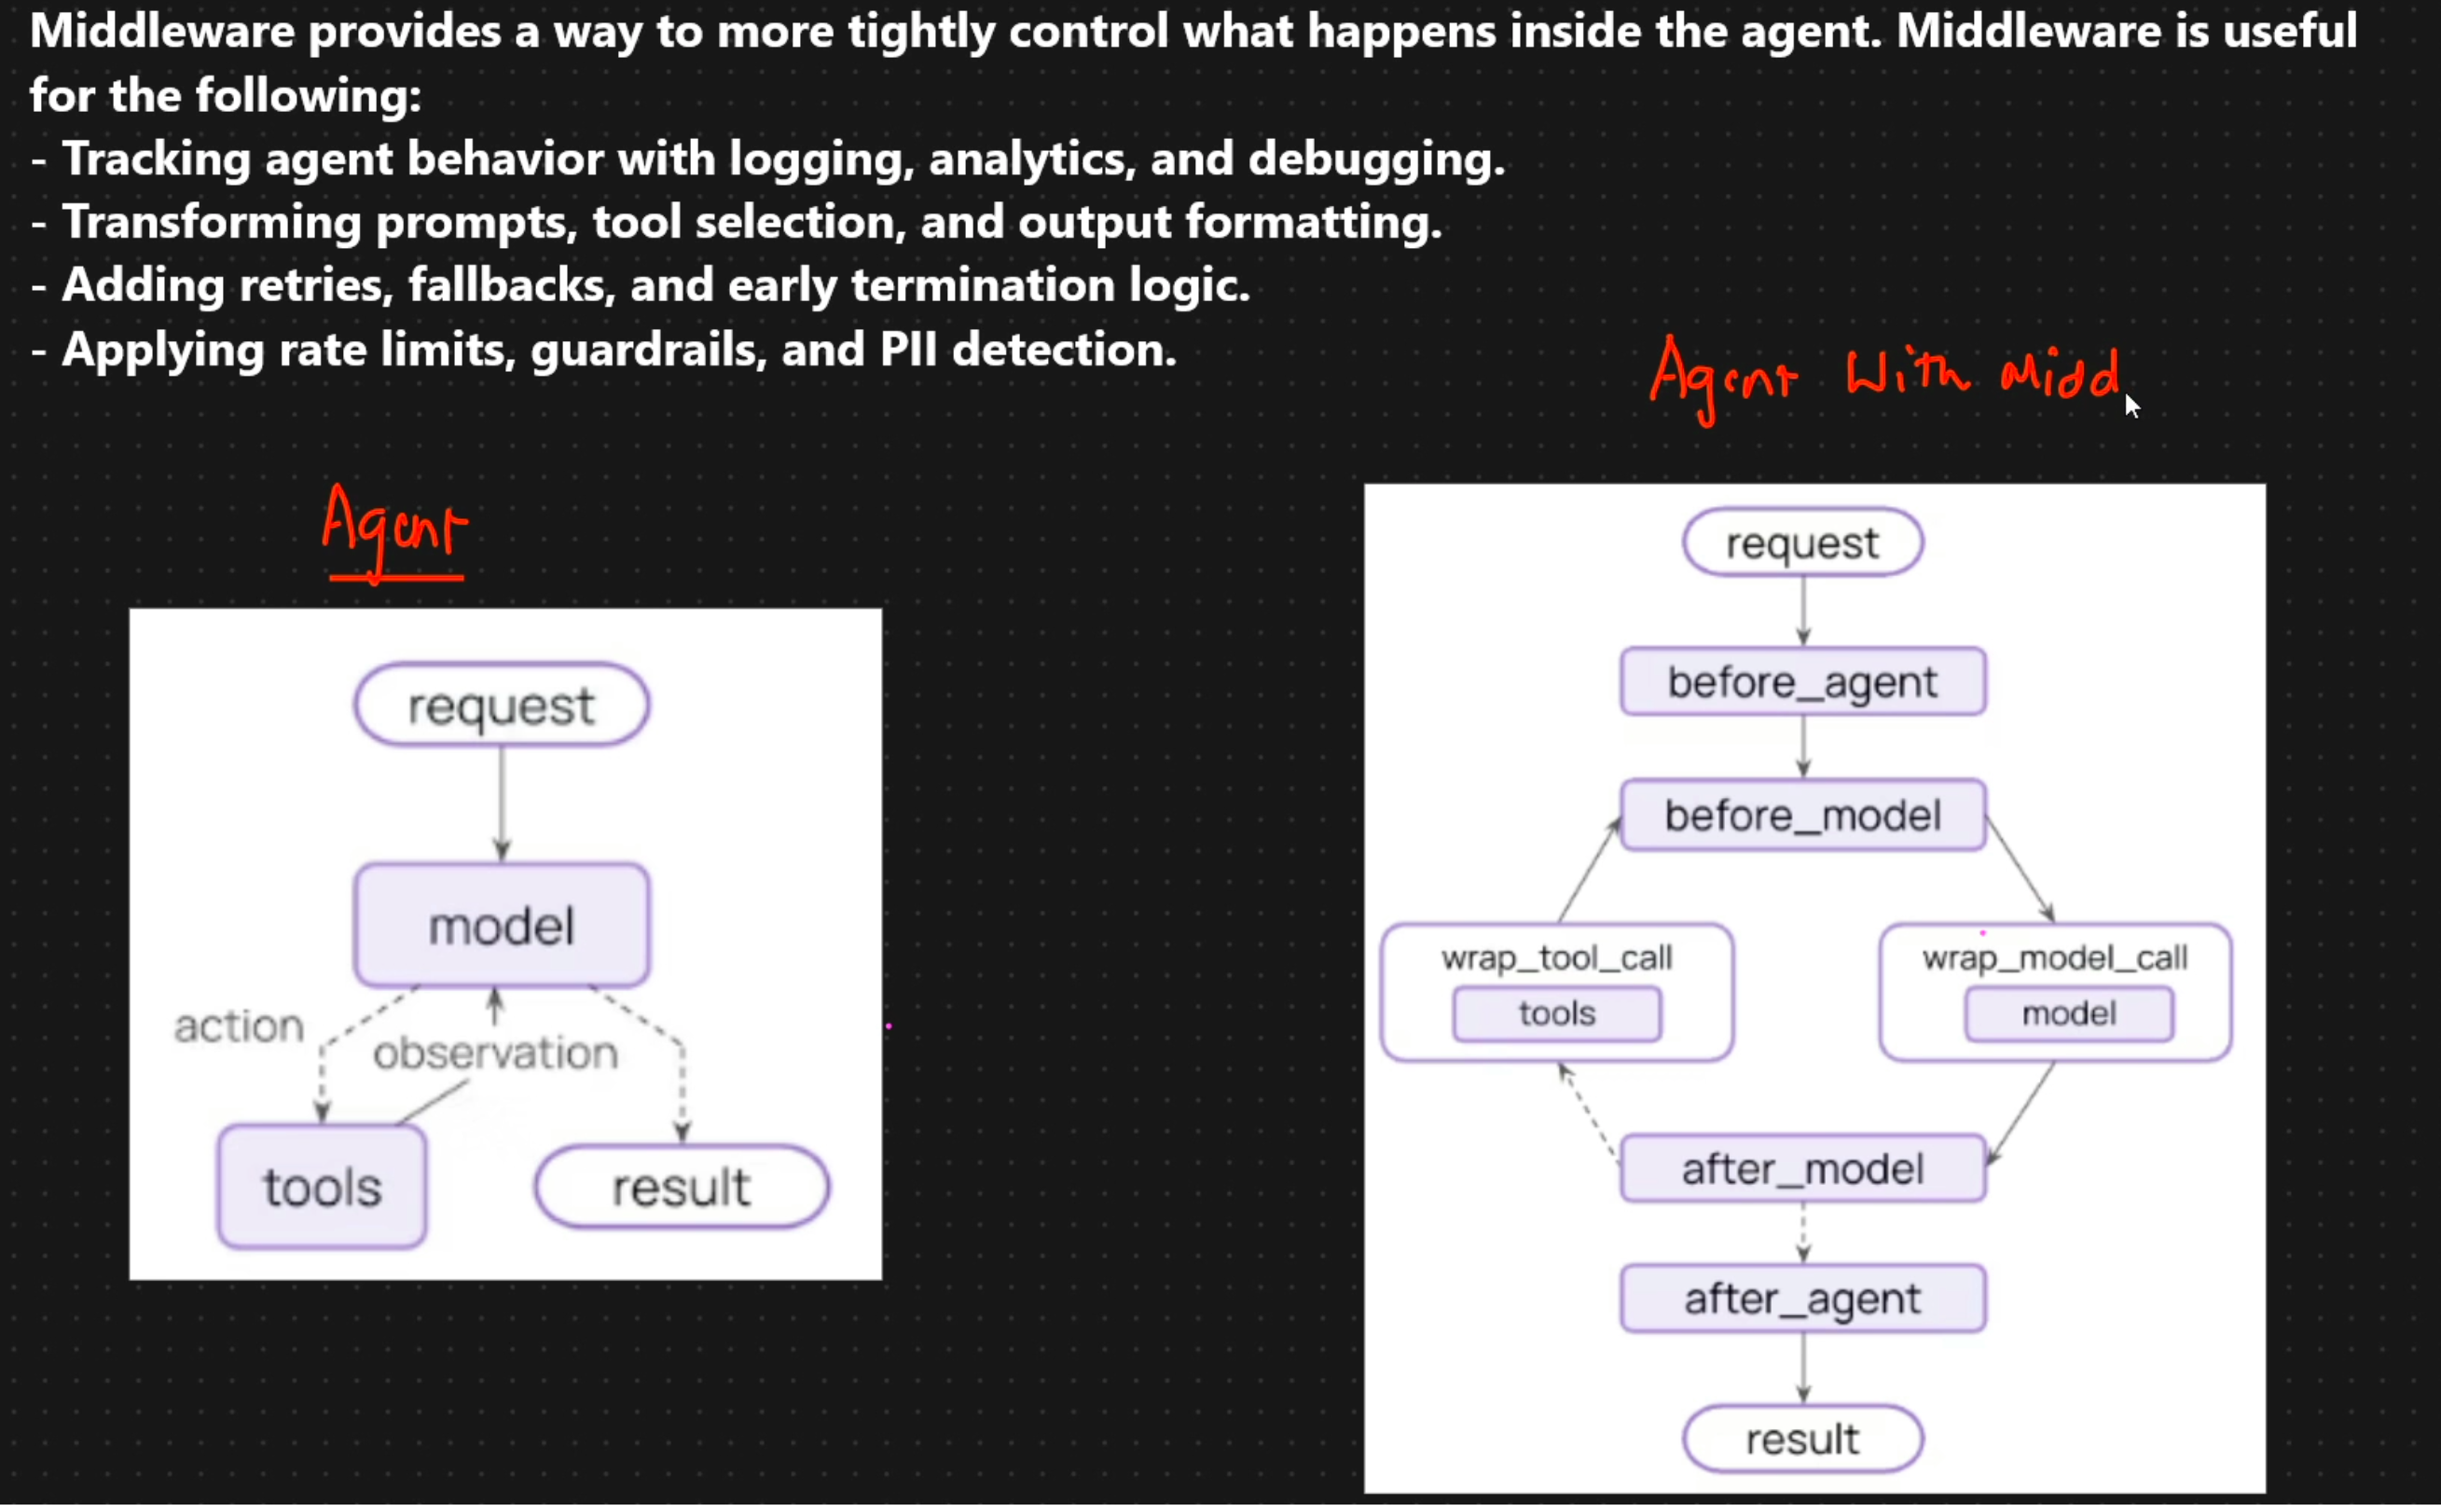

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

## Summarization Middleware

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following
- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- applications where preserving full conversation context matters

In [4]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

agent = create_agent(
    model="gpt-5.4-nano",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-5.4-nano",
            trigger=("messages", 10),
            keep=("messages", 4)
        )
    ]
)

In [9]:
### Run with thread id
config = {"configurable":{"thread_id":"thread-2"}}

In [10]:
### Alternative test data
questions = [
    "What is the capital of France?",
    "What is the largest mammal?",
    "Who is the current president of the United States?",
    "What is the tallest mountain in the world?",
    "What is the smallest country in the world?",
    "What is the longest river in the world?",
    "Who is the author of 'To Kill a Mockingbird'?",
    "What is the currency of Japan?",
    "What is the chemical symbol for gold?",
    "Who painted the Mona Lisa?"
]

for q in questions:
    response = agent.invoke({"messages": [HumanMessage(content=q)]}, config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")

Messages: {'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='ab30285f-02e7-46af-9fa7-968db14adff8'), AIMessage(content='The capital of France is **Paris**.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 13, 'total_tokens': 25, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-Df8d8TYapCw0DJXVME21juaRYCRrB', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e229a-3dfd-7613-a21b-8d627c05d105-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 12, 'total_tokens': 25, 'input_token_details': {'audio': 0, 'cache_read'

## Token Size


In [12]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

@tool
def search_hotels(city: str) ->  str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}
1. Hotel A - 5 stars - $200 per night
2. Hotel B - 4 stars - $150 per night
3. Hotel C - 3 stars - $100 per night
"""

agent = create_agent(
    model="gpt-5.4-nano",
    checkpointer=InMemorySaver(),
    tools=[search_hotels],
    middleware=[
        SummarizationMiddleware(
            model="gpt-5.4-nano",
            trigger=("tokens", 500),
            keep=("tokens", 200)
        )
    ]
)

config = {"configurable":{"thread_id":"thread-3"}}

# Token counter (aprox)
def count_tokens(messages):
    total_chars = sum(len(str(m.content )) for m in messages)
    return total_chars // 4 # Approx 4 chars per token


In [15]:
# Run test
cities = ["New York", "Paris", "Tokyo", "London", "Sydney", "Berlin", "Rome", "Barcelona", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke({"messages": [HumanMessage(content=f"Search hotels in {city}")]}, config)

    tokens = count_tokens(response['messages'])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response["messages"])}")  

New York: ~449 tokens, 8 messages
[HumanMessage(content='Here is a summary of the conversation to date:\n\n## SESSION INTENT\nProvide generic hotel options for **Sydney** using an **unfiltered** approach (city only; no dates/budget/preferences), presenting **three** options in a consistent **Hotel A/B/C** format ordered by **descending star rating and price**.\n\n## SUMMARY\n- The user is continuing the existing pattern: “Search hotels in [City]”.\n- For the new request, the required strategy is still **unfiltered**: use only the **city** (Sydney) with no additional constraints (no dates, budget, neighborhoods, amenities, or star-rating preferences).\n- Expected output: exactly **three** hotels labeled **Hotel A/B/C**, ordered by **descending star rating and price**.\n- Prior London example established the response structure and descending ordering (5-star highest price → 3-star lowest price), with no alternative strategies or rejected options.\n\n## ARTIFACTS\n- Tool call referenced i

## Fraction

The fraction trigger activates summarization once the conversation reaches a specified portion of the model’s context window, for example 80% of available tokens.

In [18]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage

agent = create_agent(
    model="gpt-5.4-nano",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-5.4-nano",
            trigger=("fraction", 0.005),
            keep=("tokens", 100)
        )
    ]
)
config = {"configurable":{"thread_id":"thread-4"}}

response = agent.invoke({"messages": [HumanMessage(content="Tell me about the history of Paris.")]}, config)
print(response)


{'messages': [HumanMessage(content='Tell me about the history of Paris.', additional_kwargs={}, response_metadata={}, id='25d29e83-cd92-46e5-b3b2-dd0b90bba3c7'), AIMessage(content='Paris has a long, layered history—shaped by conquest, revolution, empire, and waves of immigration—while repeatedly reinventing itself. Here’s a clear timeline of its major phases.\n\n## Origins and Roman Paris (c. 3rd century BCE – 5th century CE)\n- **Before Rome:** The area was inhabited by **Gauls**, especially the **Parisii** tribe, living along the **Seine**.\n- **Roman era:** Around the time Rome consolidated the region (late 1st century BCE to early 1st century CE), the settlement developed into **Lutetia Parisiorum**.\n- **City life:** Under Roman rule, roads, urban planning, and public buildings shaped the city. The Seine remained central for trade and movement.\n- **Christian roots:** By late Roman times, Christianity spread; later legend ties early martyrs in Paris to the city’s Christian beginni